## LightGBM Regression Exercise

![Namespace Labs](../../../../labs.png)

## Predict the price

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

In [2]:
df = pd.read_csv('autos.csv')

In [3]:
df.head()

,symboling,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,...,130,mpfi,3.47,2.68,9.0,111.0,5000,21,27,13495
1,3,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,...,130,mpfi,3.47,2.68,9.0,111.0,5000,21,27,16500
2,1,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,171.2,...,152,mpfi,2.68,3.47,9.0,154.0,5000,19,26,16500
3,2,audi,gas,std,four,sedan,fwd,front,99.8,176.6,...,109,mpfi,3.19,3.40,10.0,102.0,5500,24,30,13950
4,2,audi,gas,std,four,sedan,4wd,front,99.4,176.6,...,136,mpfi,3.19,3.40,8.0,115.0,5500,18,22,17450


In [4]:
# Print the head of the dataset

In [5]:
df.describe()

,symboling,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329171,3.255317,10.142537,104.256098,5125.365854,25.219512,30.751220,13207.126829
std,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.270875,0.313598,3.972040,39.519211,476.979095,6.542142,6.886443,7868.768212
min,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10595.000000
75%,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16500.000000
max,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


In [6]:
# Describe the dataset


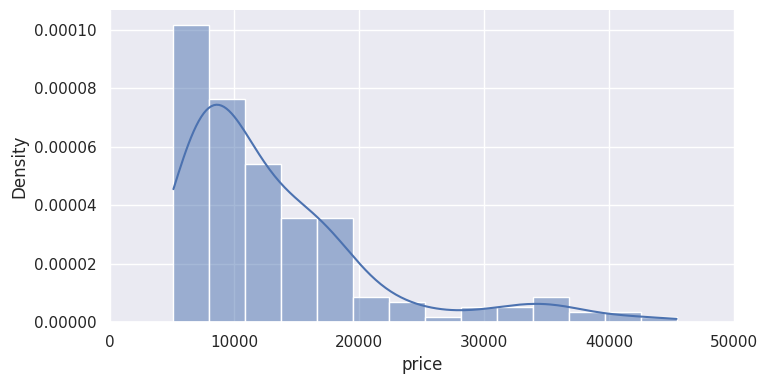

In [3]:
fig = sns.displot(data=df, x='price', kind='hist', kde=True, stat='density', height=4, aspect=1.9)
fig.set(xlim=(0, 50000))

In [8]:
# Plot a distribution of the price


In [4]:
# Create a variable of the categorical features
cats = df.select_dtypes(exclude=['int', 'float']).columns

In [5]:
# Create dummy variables
# Name the new dataframe auto
df_auto = pd.get_dummies(data=df, columns=cats, drop_first=True)
df_auto.head()

,symboling,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,compression-ratio,...,num-of-cylinders_three,num-of-cylinders_twelve,num-of-cylinders_two,fuel-system_2bbl,fuel-system_4bbl,fuel-system_idi,fuel-system_mfi,fuel-system_mpfi,fuel-system_spdi,fuel-system_spfi
0,3,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,9.0,...,False,False,False,False,False,False,False,True,False,False
1,3,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,9.0,...,False,False,False,False,False,False,False,True,False,False
2,1,94.5,171.2,65.5,52.4,2823,152,2.68,3.47,9.0,...,False,False,False,False,False,False,False,True,False,False
3,2,99.8,176.6,66.2,54.3,2337,109,3.19,3.40,10.0,...,False,False,False,False,False,False,False,True,False,False
4,2,99.4,176.6,66.4,54.3,2824,136,3.19,3.40,8.0,...,False,False,False,False,False,False,False,True,False,False


In [6]:
# Create the X variable
X = df_auto.drop(['symboling', 'price'], axis=1)

In [7]:
# Create the y variable
y = df_auto.price

In [8]:
# Import train_test_split
from sklearn.model_selection import train_test_split

In [9]:
# Split the dataset into a training and testing set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [10]:
# Import the LGBMRegressor
from lightgbm import LGBMRegressor

In [11]:
# Create an instance of LGBMRegressor
model = LGBMRegressor()

In [12]:
model.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006662 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 351
[LightGBM] [Info] Number of data points in the train set: 137, number of used features: 23
[LightGBM] [Info] Start training from score 13357.255474
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [19]:
# Fit the dataset to the model

In [13]:
# Make predictions
# Save them in a predictions dataframe
predictions = model.predict(X_test)

In [14]:
model.score(X_test, y_test)

0.8649285761652364

In [15]:
# Import the regression metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error

In [16]:
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = root_mean_squared_error(y_test, predictions)

In [17]:
print(f'The Mean Absolute Error is {mae}')
print(f'The Mean Squarred Error is {mse}')
print(f'Root Mean Squared Error is {rmse}')

The Mean Absolute Error is 1934.6602293600624
The Mean Squarred Error is 8758443.028150251
Root Mean Squared Error is 2959.46667968238


In [25]:
# Print the metrics


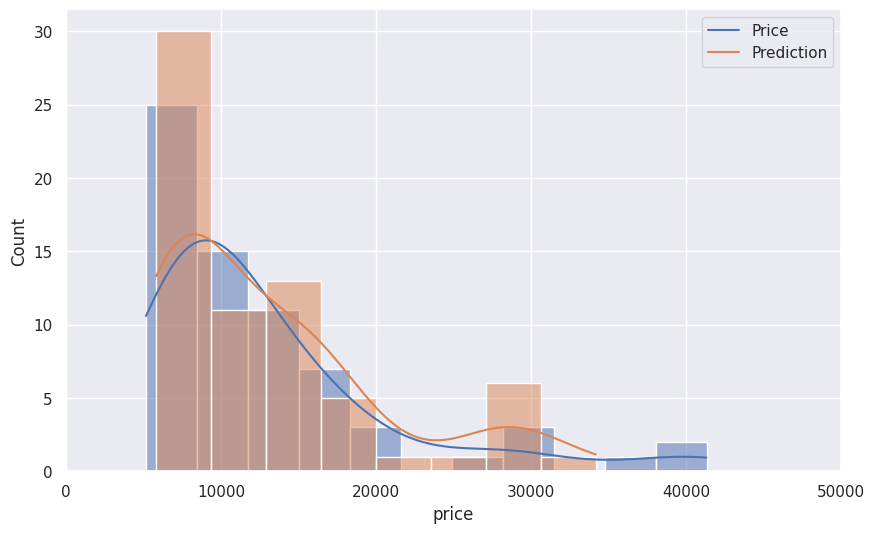

In [21]:
plt.figure(figsize=(10, 6))
sns.histplot(y_test, kde=True)
sns.histplot(predictions, kde=True)
plt.legend(labels=['Price', 'Prediction'])
plt.xlim(0, 50000)
plt.show()

In [26]:
# Plot the distribution plot of the 
# Predicted price and the real price

<Axes: xlabel='price', ylabel='Count'>

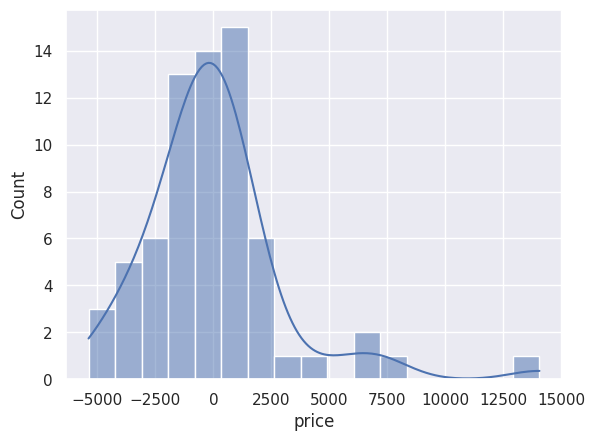

In [24]:
sns.histplot(y_test - predictions, kde=True)

In [29]:
# Plot a distribution of the differences between
# the true values and the predicted values


Text(0, 0.5, 'Predicted Price')

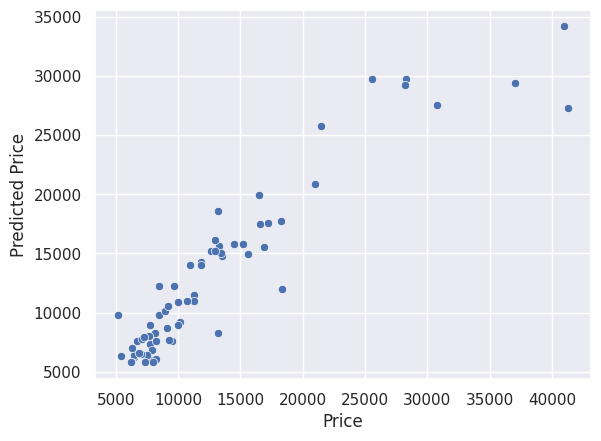

In [30]:
fig = sns.scatterplot(x=y_test, y=predictions)
fig.set_xlabel('Price')
fig.set_ylabel('Predicted Price')

In [31]:
# Plot the scatterplot of the predictions
# And the true values


In [61]:
importances = model.feature_importances_
features = X.columns

In [62]:
# Create a dataframe of the importances
importances_df = pd.DataFrame({'Feature': features, 'Importance': importances})
importances_df = importances_df.sort_values(by='Importance', ascending=False).head(15)

<Axes: xlabel='Importance', ylabel='Feature'>

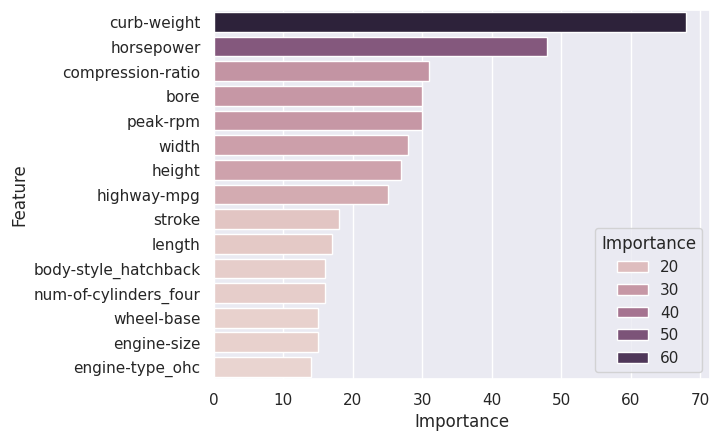

In [63]:
# Plot the importances
sns.barplot(data=importances_df, y='Feature', x='Importance', hue='Importance')

Happy coding!